In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import k_means
from sklearn.model_selection import (train_test_split,GridSearchCV)
from sklearn.preprocessing import (StandardScaler)
from sklearn.pipeline import Pipeline
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

In [3]:
df=pd.read_csv("Mall_customers.csv")
df

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [4]:
print("Shape of the dataframe is ",df.shape)
print("-"*64)
print("Column names are\n",df.columns)
print("Information of the dataset")
print("-"*64)
df.info()

Shape of the dataframe is  (200, 5)
----------------------------------------------------------------
Column names are
 Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')
Information of the dataset
----------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


<Axes: xlabel='Spending Score (1-100)', ylabel='Annual Income (k$)'>

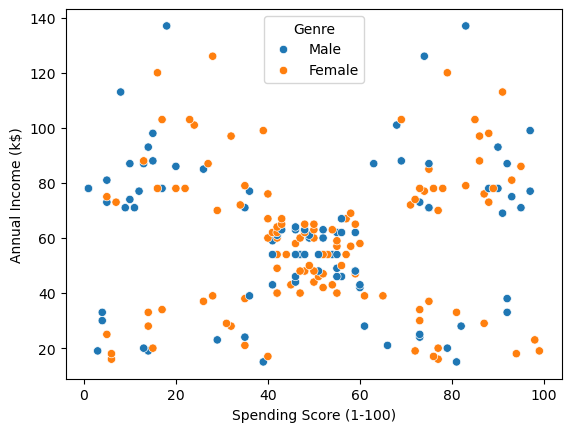

In [5]:
sns.scatterplot(x="Spending Score (1-100)",y="Annual Income (k$)",data=df,hue="Genre")

<Axes: xlabel='Spending Score (1-100)', ylabel='Annual Income (k$)'>

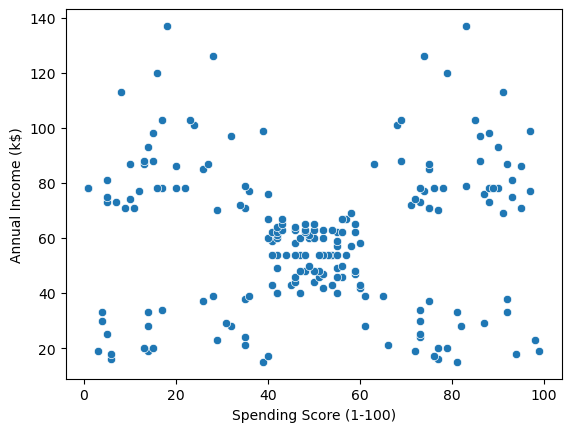

In [6]:
sns.scatterplot(x="Spending Score (1-100)",y="Annual Income (k$)",data=df)

<Axes: xlabel='Spending Score (1-100)', ylabel='Age'>

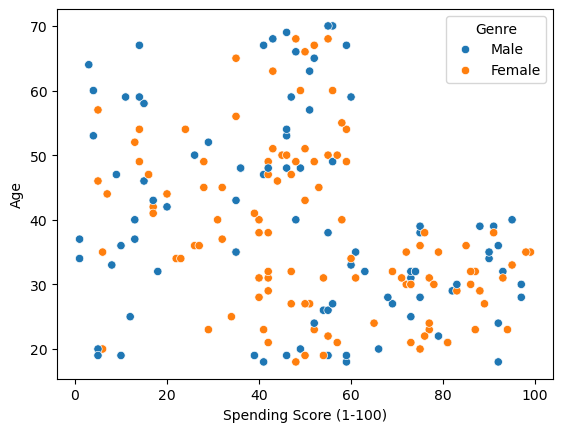

In [7]:
sns.scatterplot(x="Spending Score (1-100)",y="Age",data=df,hue="Genre")

<Axes: ylabel='Spending Score (1-100)'>

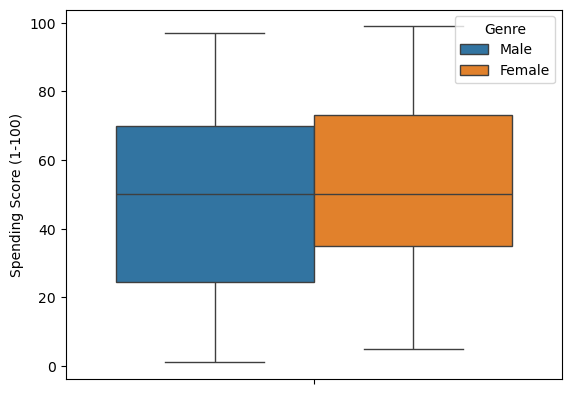

In [8]:
sns.boxplot(y="Spending Score (1-100)",hue="Genre",data=df)

<Axes: xlabel='Annual Income (k$)', ylabel='Count'>

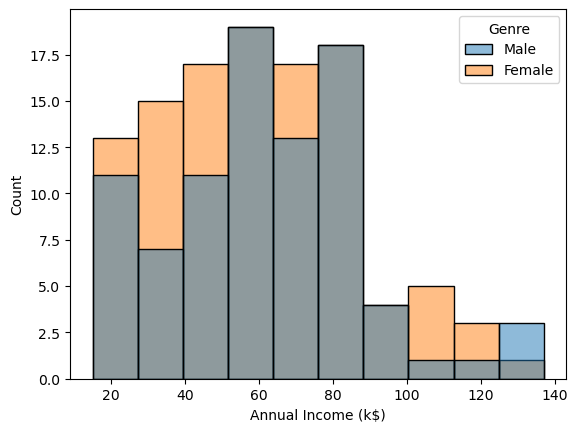

In [9]:
sns.histplot(x="Annual Income (k$)",hue="Genre",data=df)

<Axes: ylabel='Age'>

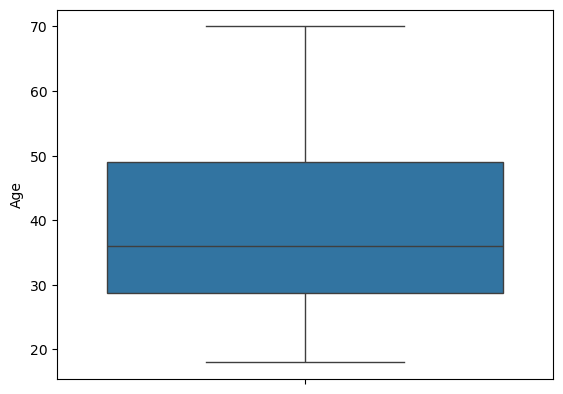

In [10]:
sns.boxplot(y="Age",data=df)

<Axes: xlabel='Age', ylabel='Count'>

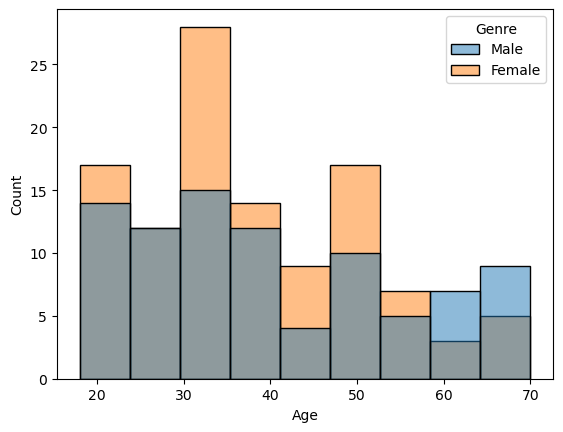

In [11]:
sns.histplot(x="Age",hue="Genre",data=df)

<Axes: xlabel='Age', ylabel='Spending Score (1-100)'>

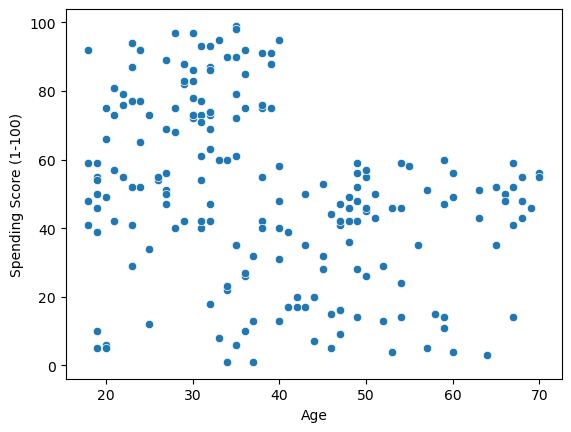

In [12]:
sns.scatterplot(x="Age",y="Spending Score (1-100)",data=df)

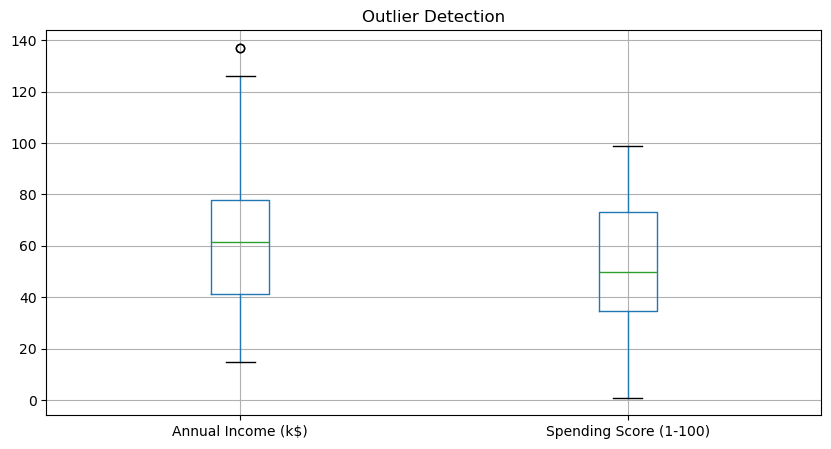

In [13]:
plt.figure(figsize=(10, 5))
df[['Annual Income (k$)', 'Spending Score (1-100)']].boxplot()
plt.title("Outlier Detection")
plt.show()

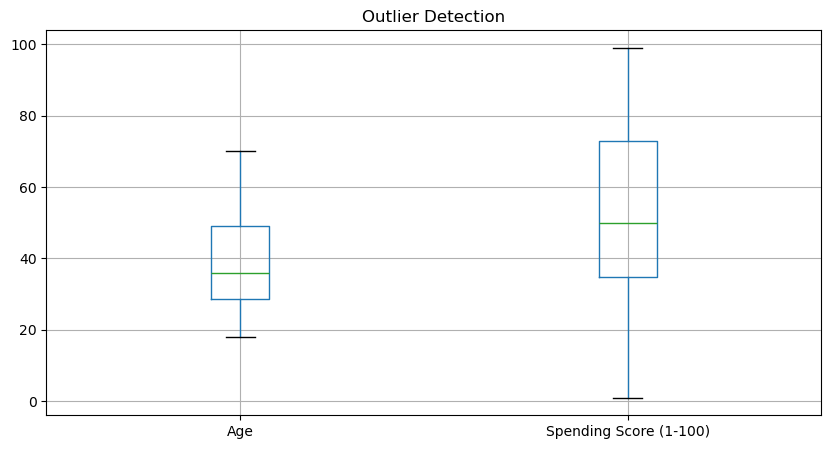

In [14]:
plt.figure(figsize=(10, 5))
df[['Age', 'Spending Score (1-100)']].boxplot()
plt.title("Outlier Detection")
plt.show()

In [15]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]
X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [16]:
k_means = KMeans()
# Pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', k_means)
])

# Custom silhouette scorer
def silhouette_scorer(estimator, X, y=None):
    clusters = estimator.predict(X)
    return silhouette_score(X, clusters)

# Parameters to test
param_grid = {
    "model__n_clusters": np.arange(2, 7),
    "model__n_init": np.arange(5, 10),
    "model__random_state": [42]
}

# Grid Search
grid = GridSearchCV(
    pipeline,
    param_grid,
    scoring=silhouette_scorer
)

# Train
grid.fit(X)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/model_selection/_validation.py:953: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 940, in _score
    scores = scorer(estimator, X_test, **score_params)
  File "/var/folders/c6/nt0k_yy91x16phw4mhjl9_hh0000gn/T/ipykernel_29275/1401224357.py", line 11, in silhouette_scorer
    return silhouette_score(X, clusters)
  File "/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/_param_validation.py", line 218, in wrapper
    return func(*args, **kwargs)
  File "/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/cluster/_unsupervised.py", line 138, in silhouette_score
    return float(np.mean(silhouette_samples(X, labels, metric=metric, **kwds)))
                         ~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  Fi

,estimator,"Pipeline(step...', KMeans())])"
,param_grid,"{'model__n_clusters': array([2, 3, 4, 5, 6]), 'model__n_init': array([5, 6, 7, 8, 9]), 'model__random_state': [42]}"
,scoring,<function sil...t 0x17851b4c0>
,n_jobs,None
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


{'model__n_clusters': np.int64(2),
 'model__n_init': np.int64(5),
 'model__random_state': 42}

In [18]:
grid.best_score_

np.float64(nan)

In [24]:
scaler=StandardScaler()
clusters = kmeans.fit_predict(X_scaled)
df['Cluster']= clusters
df.head()
cluster_summary= df.groupby('Cluster')[
['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
].mean()
cluster_summary
X_scaled=scaler.fit_transform(X)
kmeans = KMeans(
n_clusters=5,
random_state=42,
n_init=10
)
silhouette = silhouette_score(X_scaled, clusters)
print("Silhouette Score:", silhouette)

Silhouette Score: 0.5546571631111091
